Topic 0: tiktok, tiktok ban, video, ban tiktok, platform, china, chinese, american, banned, content
Topic 1: dont, free, think, love, speech, right, free speech, truth, medium, care
Topic 2: ban, ban tiktok, tiktok ban, court, government, app, supreme, supreme court, appeal, law
Topic 3: trump, china, right, chinese, president, american, going, way, election, doesnt
Topic 4: banned, time, thank, instagram, come, long, issue, shadow, help, shadow banned


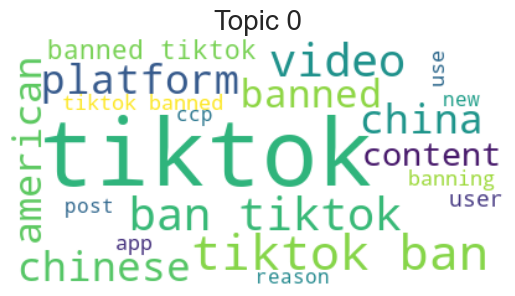

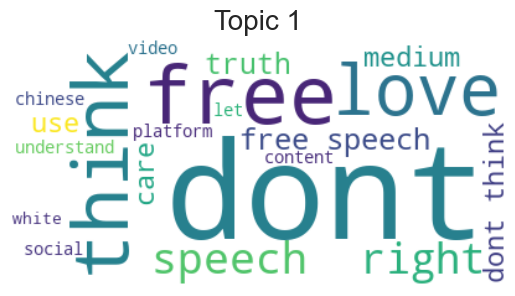

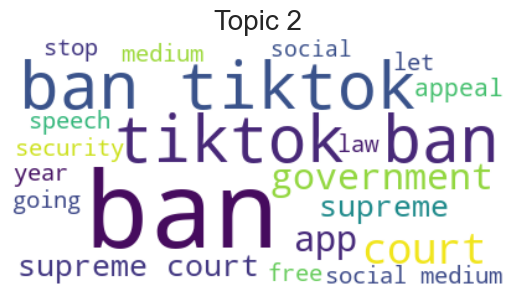

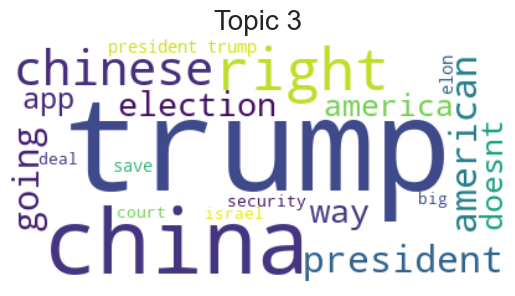

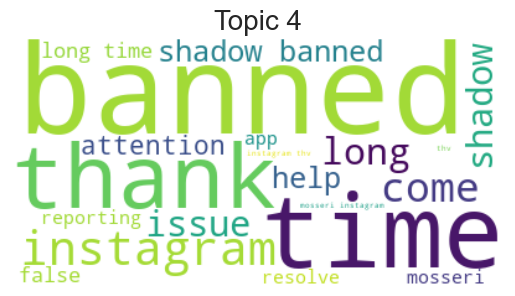


Topic 0
- this cycle is Cat Season, and $SHIRO will be #1 Cat on crypto 

0xb0AC2b5a73da0e67A8e5489Ba922B3f8d582e058

#ShiroNeko 
@shiro
 @binance
- This is was abvious from the begining.

I remember watching a Candice Owens video, and she showed a leaked voice memo from someone from AIPAC, saying that they need to do “something” about TikTok, and how it is ruining the war
- TikTok in Cantonese means Brain Aids. Fact check that you monsters.

Topic 1
- don't fall in to the data privacy trap there are hundreds of foreign apps that collect data problem is that tiktok was center of anti genocide movement and zionist masters are not happy.
- flashback by afterschool - no bc LETS get into it
- Yes I agree with doge

Topic 2
- I've been following you on TikTok for quite a while now. Great content! Not sure why they'd ever need to ban you. It's not like you're that controversial, you're just sharing current events??
- Why they want to ban TikTok Part 2
- The TikTok ban is not just about that

In [79]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction import text
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("2.xlsx")  
texts = df["Cleaned_Comment_v2"].astype(str)

custom_stopwords = ["lol", "bts", "thing", "want", "like", "good", "really", "look", "day", "morning"]
stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))

# TF-IDF 
vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=25,
    stop_words=stop_words,
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

# Training the NMF model
nmf_model = NMF(n_components=5, random_state=42, max_iter=600, init="nndsvda", solver="mu")
W = nmf_model.fit_transform(X)
H = nmf_model.components_
df["Topic"] = W.argmax(axis=1)


# Output the top 10 keywords for each topic
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topic {i}: {', '.join(top_words)}")

# visual word cloud diagram
for i, topic in enumerate(H):
    word_freq = {feature_names[j]: topic[j] for j in topic.argsort()[:-21:-1]}
    wc = WordCloud(background_color="white").generate_from_frequencies(word_freq)
    plt.figure()
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {i}")
    plt.show()


# Output 3 representative comments per topic
for i in range(5):
    print(f"\nTopic {i}")
    samples = df[df["Topic"] == i]["Comment"].dropna().sample(3, random_state=42)
    for s in samples:
        print("-", s)




In [63]:
print("NMF Reconstruction Error:", nmf_model.reconstruction_err_)

NMF Reconstruction Error: 89.4869022581911


   Topic                           Topic_Name
0      0  TikTok Platform & National Identity
1      2         Legal & Judicial Proceedings
2      0  TikTok Platform & National Identity
3      1    Free Speech & Personal Expression
4      2         Legal & Judicial Proceedings


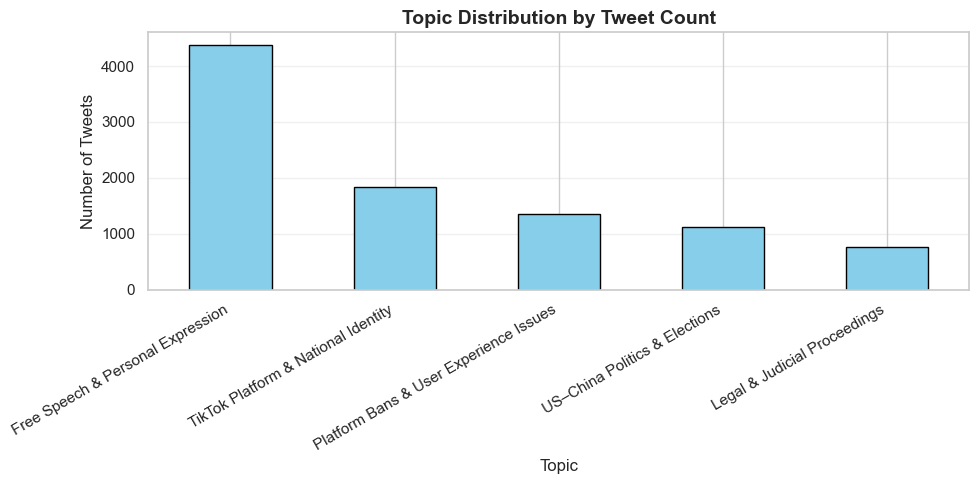

In [27]:
topic_names = { 
    0: "TikTok Platform & National Identity",
    1: "Free Speech & Personal Expression",
    2: "Legal & Judicial Proceedings",
    3: "US–China Politics & Elections",
    4: "Platform Bans & User Experience Issues"
}

df['Topic_Name'] = df['Topic'].map(topic_names)

print(df[['Topic', 'Topic_Name']].head())

# Visualisation: distribution of tweets by topic
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df['Topic_Name'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Topic Distribution by Tweet Count", fontsize=14, fontweight='bold')
plt.ylabel("Number of Tweets")
plt.xlabel("Topic")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [77]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_terms_comparison(H, X, feature_names, topic_names, top_n=30):
   
    n_topics = H.shape[0]
    corpus_freq = X.toarray().mean(axis=0)   # Mean TF-IDF frequency for each word in the overall corpus

    for topic_idx in range(n_topics):
        top_indices = H[topic_idx].argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = H[topic_idx][top_indices]
        background_freq = corpus_freq[top_indices]

        y_pos = np.arange(len(top_words))

        fig, ax = plt.subplots(figsize=(9, 10))
        ax.barh(y_pos, background_freq, color='#D5E8D4', label='Corpus Frequency')
        ax.barh(y_pos, top_weights, color='#5C8F5C', label='Topic Relevance')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_words, fontsize=11)
        ax.invert_yaxis()
        ax.set_xlabel('TF-IDF Weight')
        ax.set_title(f"Top-{top_n} Most Relevant Terms for Topic {topic_idx}: {topic_names[topic_idx]}", fontsize=14, weight='bold')
        ax.legend()
        plt.tight_layout()
        plt.show()


<Figure size 640x480 with 0 Axes>

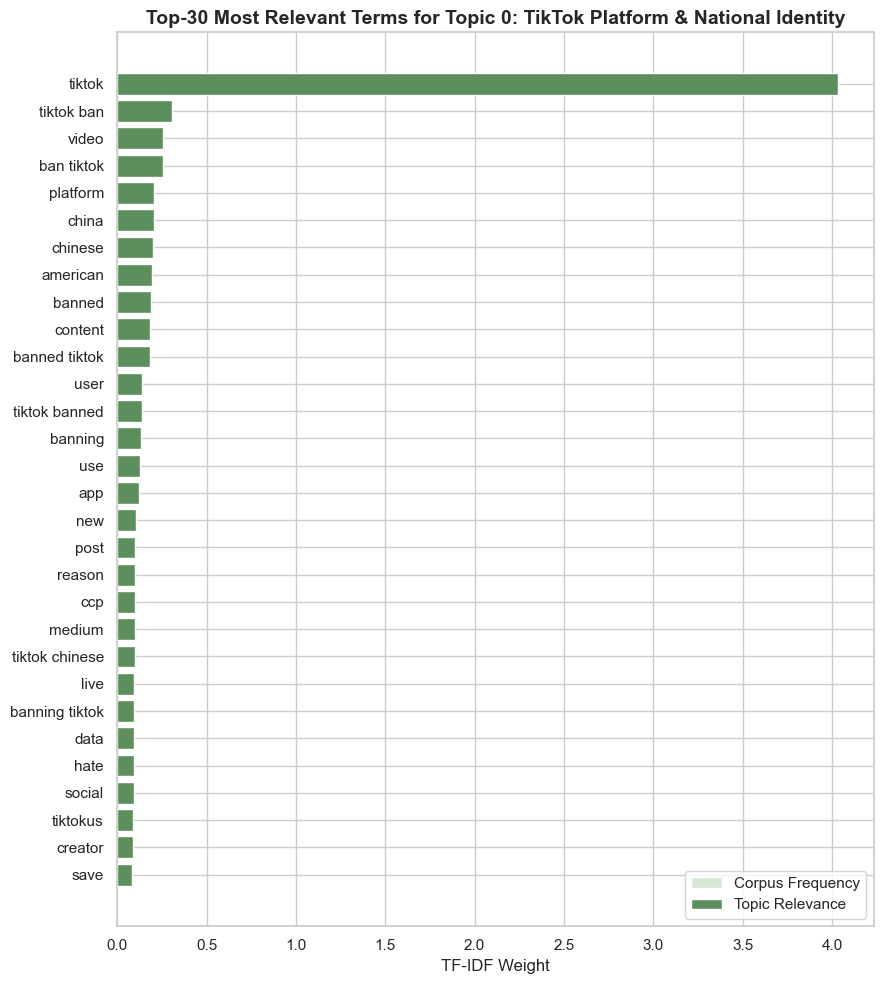

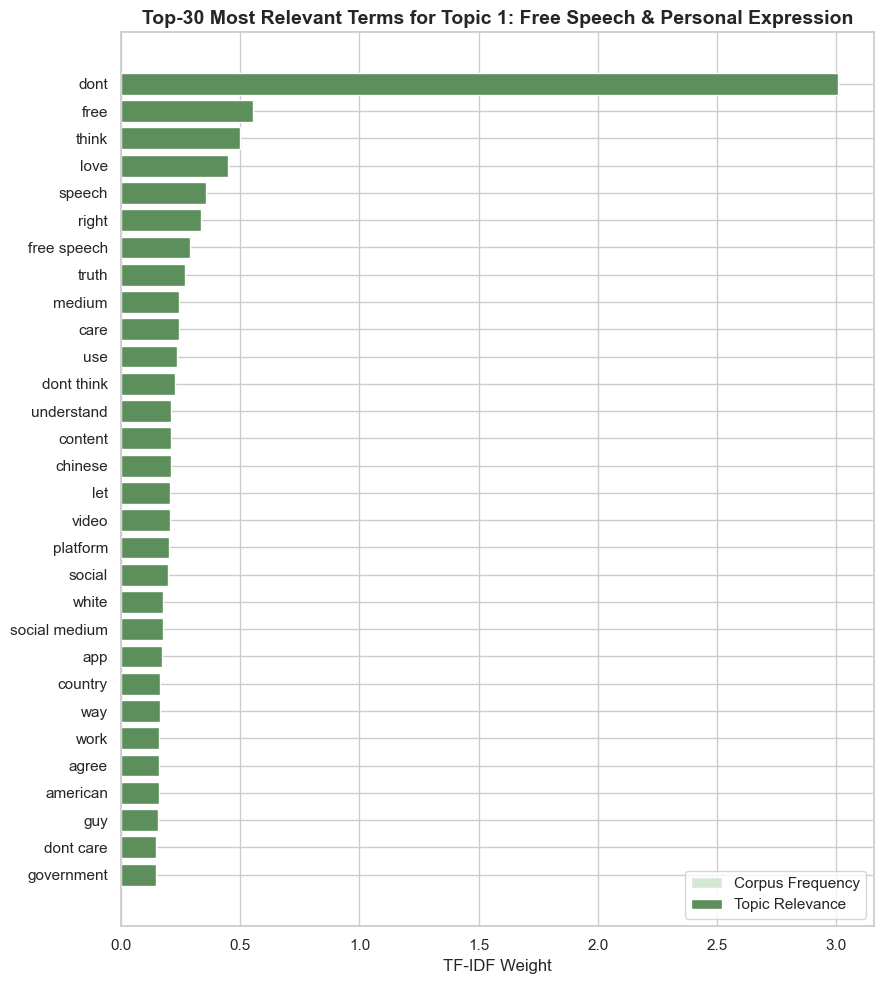

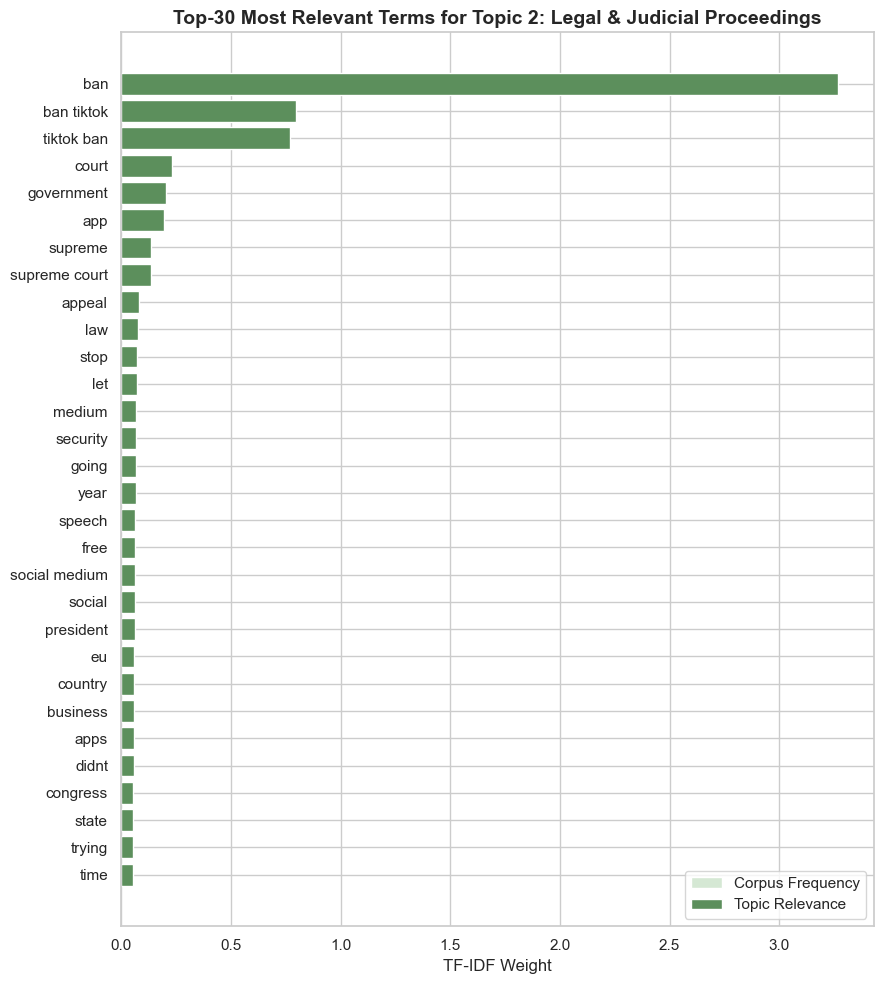

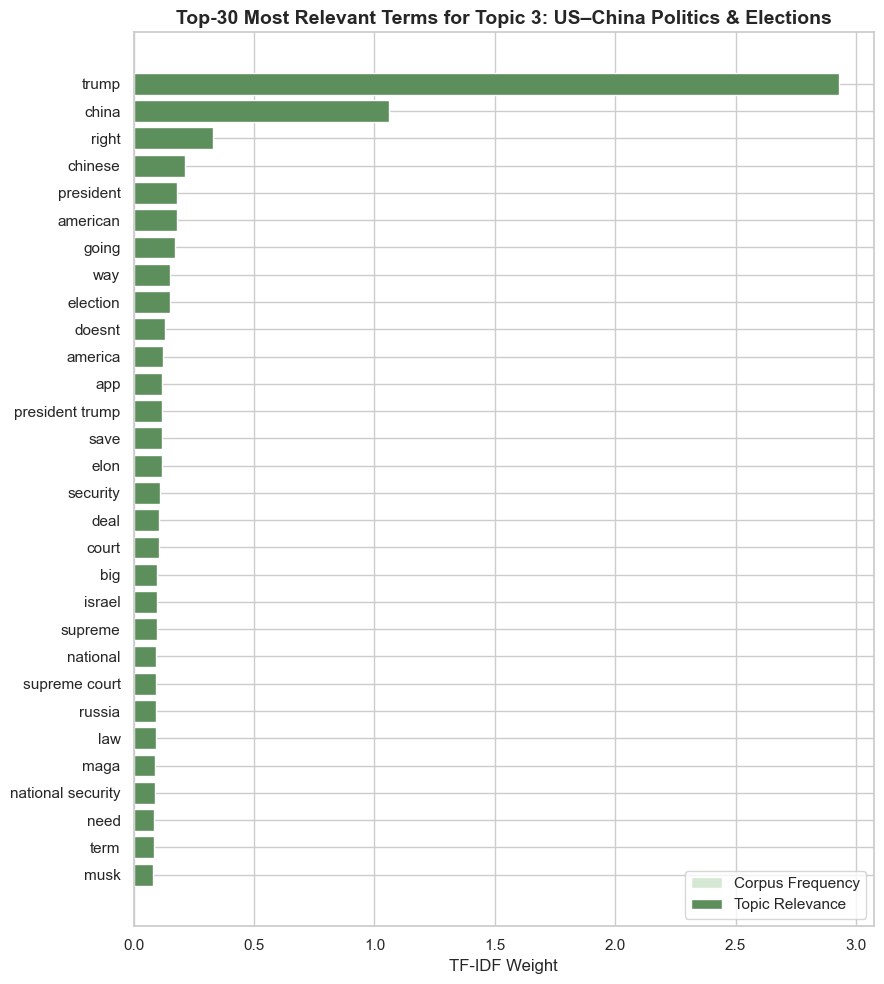

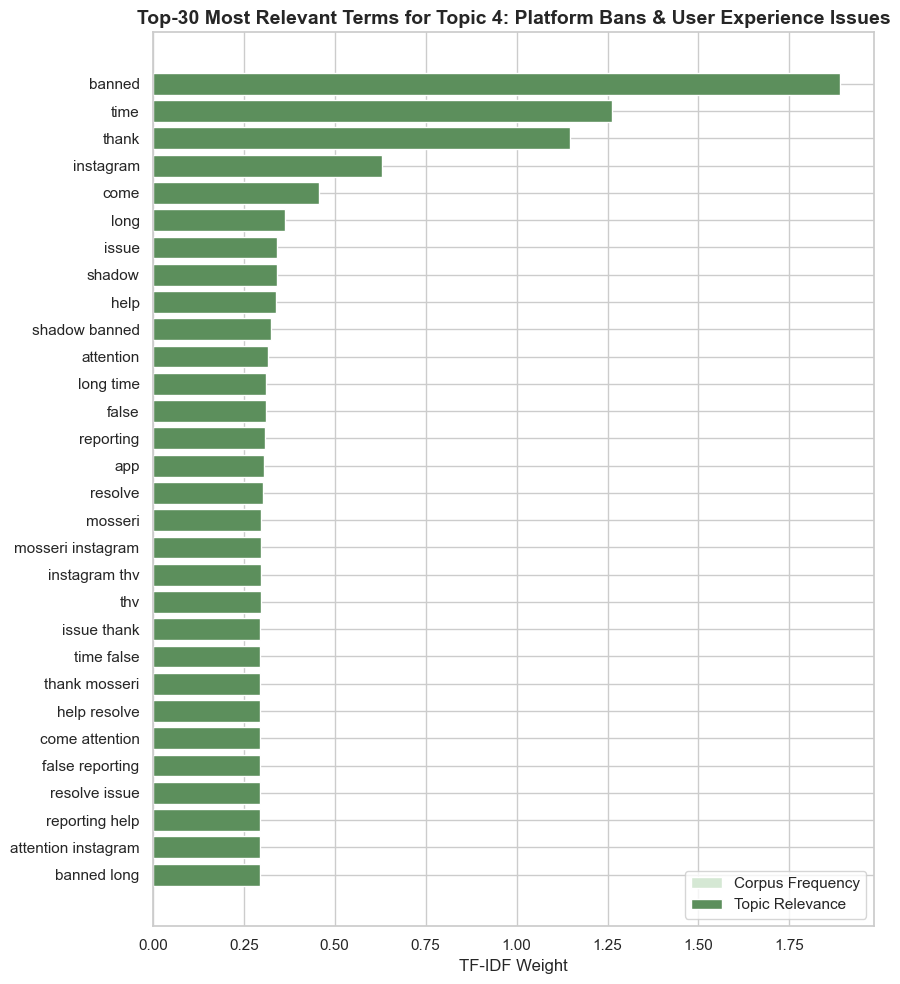

图已保存到： /Users/tianziguo/Desktop/topic_0_top_words.png


<Figure size 640x480 with 0 Axes>

In [33]:
import os
import matplotlib.pyplot as plt

desktop_path = os.path.expanduser("~/Desktop")
topic_idx = 0

topic_names = {
    0: "TikTok Platform & National Identity",
    1: "Free Speech & Personal Expression",
    2: "Legal & Judicial Proceedings",
    3: "US–China Politics & Elections",
    4: "Platform Bans & User Experience Issues"
}


plt.savefig(f"topic_{topic_idx}_top_words.png", dpi=300)
import os
import matplotlib.pyplot as plt

desktop_path = os.path.expanduser("~/Desktop")

topic_idx = 0

plot_top_terms_comparison(H, X, feature_names, topic_names)

plt.savefig(os.path.join(desktop_path, f"topic_{topic_idx}_top_words.png"), dpi=300, bbox_inches='tight')

plt.savefig(os.path.join(desktop_path, f"topic_{topic_idx}_top_words.png"), dpi=300, bbox_inches='tight')
print("The chart has been saved to：", os.path.join(desktop_path, f"topic_{topic_idx}_top_words.png"))

plt.draw()
plt.savefig(os.path.join(desktop_path, f"topic_{topic_idx}_top_words.png"), dpi=300, bbox_inches='tight')


In [91]:
for topic_idx in topic_names:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_indices = H[topic_idx].argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = H[topic_idx][top_indices]

    ax.barh(top_words[::-1], top_weights[::-1], color='#238b45')  
    ax.set_title(f"Top Terms for Topic {topic_idx}: {topic_names[topic_idx]}")
    ax.set_xlabel("Relevance")

    save_path = os.path.join(desktop_path, f"topic_{topic_idx}_{topic_names[topic_idx].replace(' ', '_')}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print("Saved：", save_path)


Saved： /Users/tianziguo/Desktop/topic_0_TikTok_Platform_&_National_Identity.png
Saved： /Users/tianziguo/Desktop/topic_1_Free_Speech_&_Personal_Expression.png
Saved： /Users/tianziguo/Desktop/topic_2_Legal_&_Judicial_Proceedings.png
Saved： /Users/tianziguo/Desktop/topic_3_US–China_Politics_&_Elections.png
Saved： /Users/tianziguo/Desktop/topic_4_Platform_Bans_&_User_Experience_Issues.png


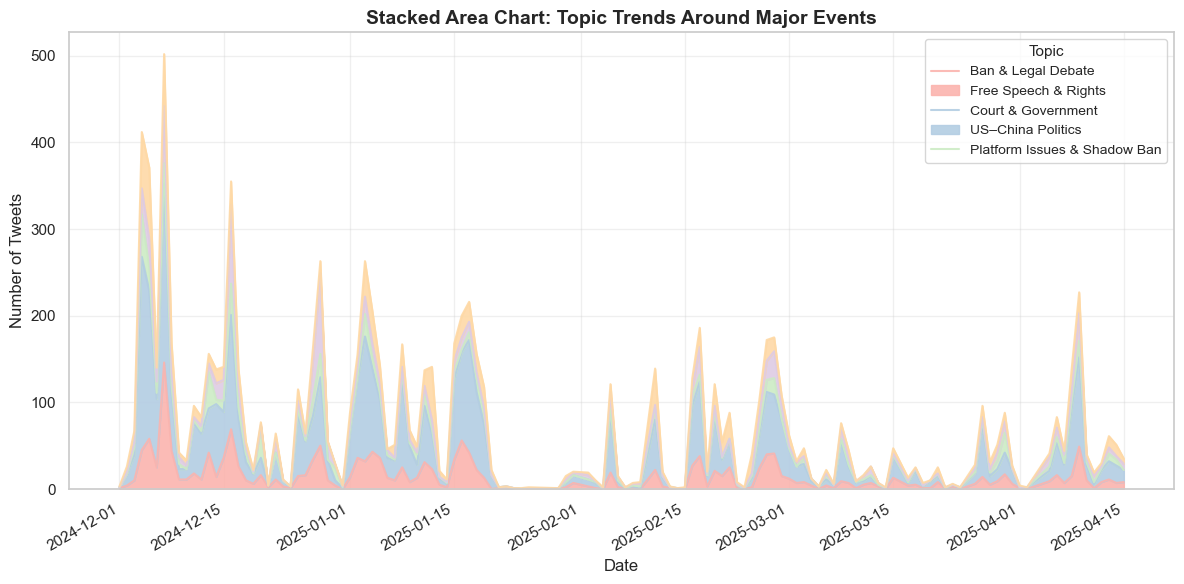

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)

# Trend data constructed
trend = df.groupby([df['date'].dt.date, 'Topic']).size().unstack(fill_value=0)
trend.index = pd.to_datetime(trend.index)

# Limited timeframe
start_date = pd.to_datetime("2024-11-01")
end_date = pd.to_datetime("2025-04-30")
trend_window = trend[(trend.index >= start_date) & (trend.index <= end_date)]

colors = [
    "#fbb4ae",  
    "#b3cde3", 
    "#ccebc5", 
    "#decbe4", 
    "#fed9a6"  
]

# Plotting:
ax = trend_window.plot.area(figsize=(12, 6), alpha=0.9, color=colors)



# Beautify graphic elements
plt.title("Stacked Area Chart: Topic Trends Around Major Events", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid(alpha=0.3)

plt.legend(title="Topic", labels=[
    "Ban & Legal Debate",
    "Free Speech & Rights",
    "Court & Government",
    "US–China Politics",
    "Platform Issues & Shadow Ban"
], fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()


/var/folders/7_/3q_mk9j57g32cmk1tz0xc6wc0000gn/T/ipykernel_4902/3812294114.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


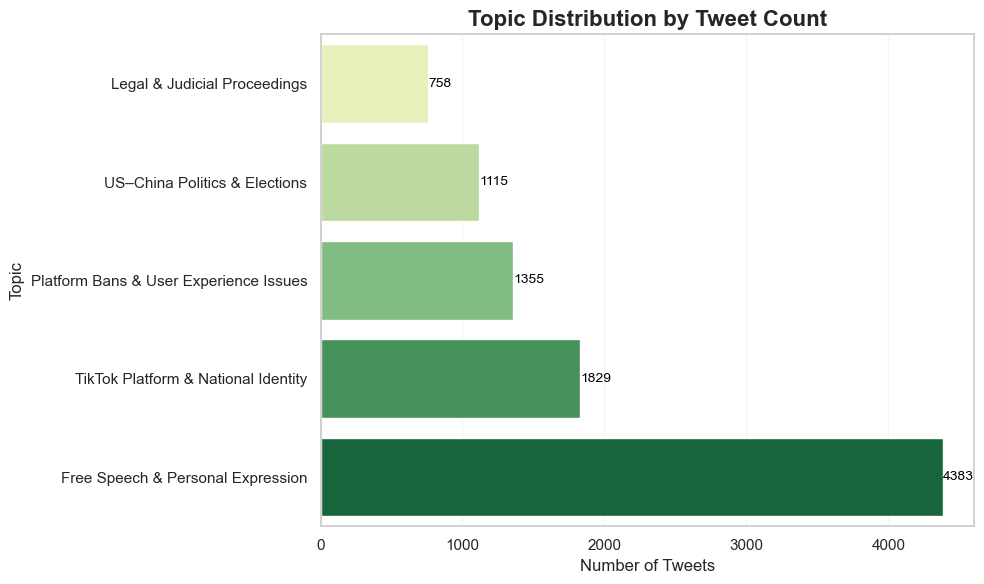

In [372]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

topic_names = { 
    0: "TikTok Platform & National Identity",
    1: "Free Speech & Personal Expression",
    2: "Legal & Judicial Proceedings",
    3: "US–China Politics & Elections",
    4: "Platform Bans & User Experience Issues"
}

df['Topic_Name'] = df['Topic'].map(topic_names)

topic_counts = df['Topic_Name'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x=topic_counts.values,
    y=topic_counts.index,
    palette='YlGn'  
)

for i, v in enumerate(topic_counts.values):
    plt.text(v + 1, i, str(v), color='black', va='center', fontsize=10)

plt.title("Topic Distribution by Tweet Count", fontsize=16, fontweight='bold')
plt.xlabel("Number of Tweets", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.tight_layout()
plt.grid(axis='x', alpha=0.2)
plt.show()

In [376]:
import os
print(os.path.expanduser("~/Desktop"))

/Users/tianziguo/Desktop


In [378]:
plt.savefig("/Users/tianziguo/Desktop/topic_distribution.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

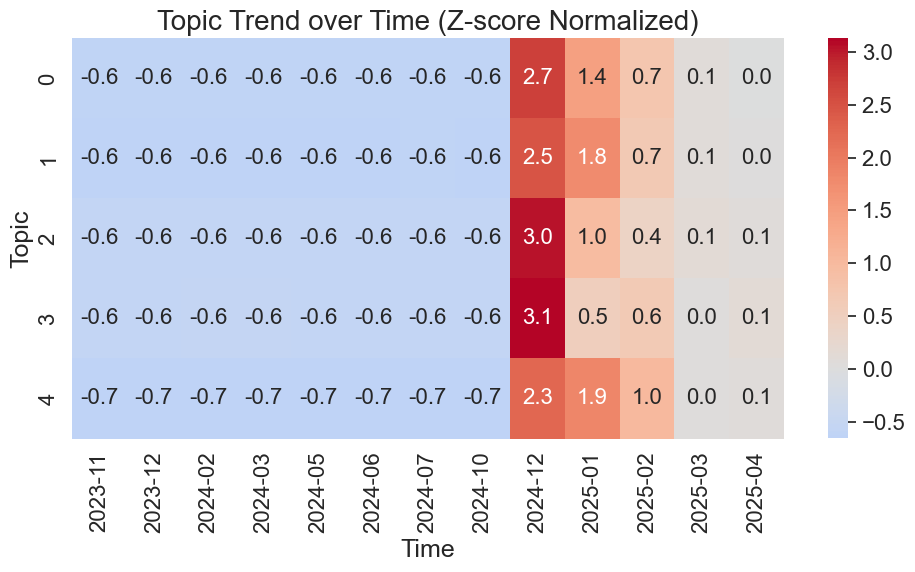

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Duplicate the DataFrame and process the time
df = df.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].dt.tz_localize(None)  # Remove time zone information
df['TimeGroup'] = df['Date'].dt.to_period('M')  # may be changed to ‘W’ to indicate weekly groupings

# Construct a time-frequency table of topics
topic_trend = df.groupby(['TimeGroup', 'Topic']).size().unstack(fill_value=0)

# Z-score standardisation
topic_zscores = topic_trend.apply(zscore, axis=0)

# Heatmap visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(topic_zscores.T, cmap='coolwarm', center=0, annot=True, fmt=".1f")
plt.title("Topic Trend over Time (Z-score Normalized)")
plt.xlabel("Time")
plt.ylabel("Topic")
plt.tight_layout()

# Save to desktop
plt.savefig("/Users/tianziguo/Desktop/topic_trend_heatmap.png", dpi=300)

plt.show()

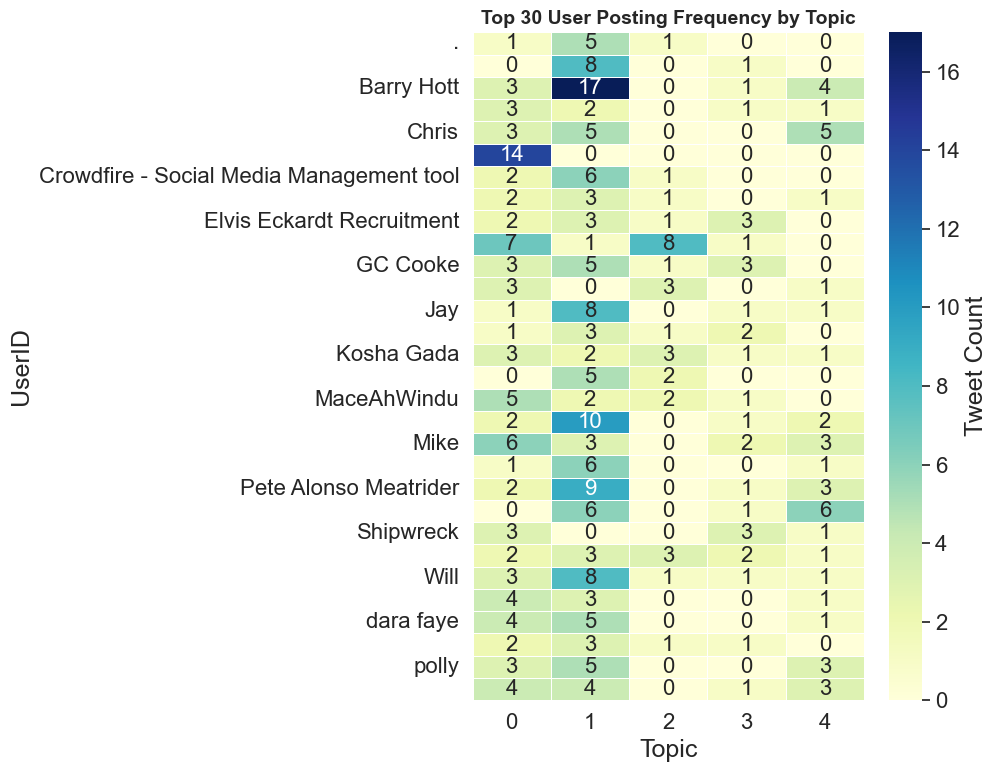

图像已保存至桌面：/Users/tianziguo/Desktop/topic_user_heatmap.png


In [101]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

top_users = df['UserID'].value_counts().head(30).index
df_top = df[df['UserID'].isin(top_users)]
heat_df = df_top.pivot_table(index='UserID', columns='Topic', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 8))

# Drawing heat maps
sns.heatmap(
    heat_df,
    cmap="YlGnBu",           
    linewidths=0.5,
    annot=True,               
    fmt="d",                 
    cbar_kws={"label": "Tweet Count"}
)

plt.title("Top 30 User Posting Frequency by Topic", fontsize=14, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("UserID")
plt.tight_layout()

desktop_path = os.path.expanduser("~/Desktop/topic_user_heatmap.png")

# Save images
plt.savefig(desktop_path, dpi=300)

# S
plt.show()

print(f"The image has been saved to the desktop：{desktop_path}")

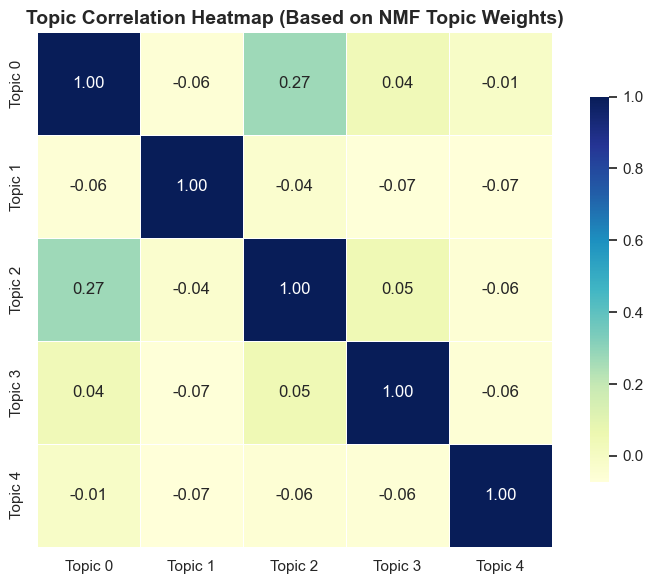

In [408]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

df = pd.read_excel("2.xlsx") 
texts = df['Cleaned_Comment_v2'].astype(str)

custom_stopwords = ['lol', 'bts', 'thing', 'want', 'like', 'good', 'really', 'look', 'day', 'morning']
stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))
vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=25,
    stop_words=stop_words,
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(texts)

nmf_model = NMF(n_components=5, random_state=42, max_iter=600)
W = nmf_model.fit_transform(X)  # (number of samples × number of topics)

# build DataFrame to store topic weights for each comment
topic_weights = pd.DataFrame(W, columns=[f"Topic {i}" for i in range(W.shape[1])])

# Calculation of the matrix of correlation coefficients between themes (Pearson correlation coefficient)
corr = topic_weights.corr()

# visualisation of heat maps
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f", square=True,
            cbar_kws={"shrink": 0.75}, linewidths=0.5)
plt.title("Topic Correlation Heatmap (Based on NMF Topic Weights)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/7_/3q_mk9j57g32cmk1tz0xc6wc0000gn/T/ipykernel_21930/2287807527.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=kmeans_labels, palette="Set2")


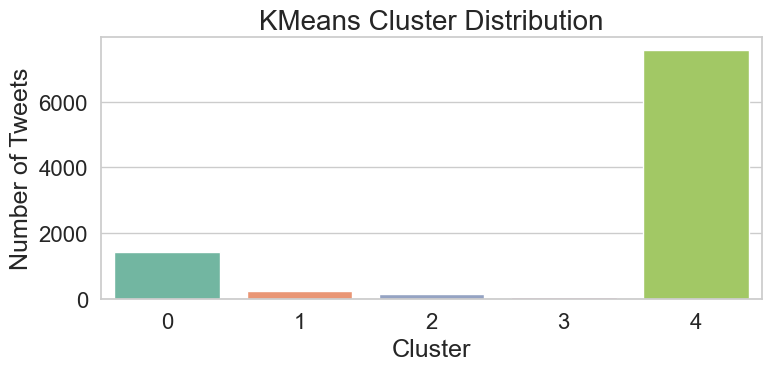

Crosstab: NMF Topics vs. KMeans Clustering
col_0    0    1    2   3     4
Topic                         
0      671   20    9   0  1129
1       55  167  120   0  4041
2      501   11    4   0   242
3      114   16    5   0   980
4       87   24    8  57  1179


In [103]:
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1,2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Comment_v2'].fillna(""))

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)

plt.figure(figsize=(8, 4))
sns.countplot(x=kmeans_labels, palette="Set2")
plt.title("KMeans Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

if 'Topic' in df.columns:
    cross_tab = pd.crosstab(df['Topic'], kmeans_labels)
    print("Crosstab: NMF Topics vs. KMeans Clustering")
    print(cross_tab)

In [97]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# tfidf_matrix = ...

# Set the number of clusters, the same as the number of NMF topics.
n_clusters = 5

# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)

# Calculate Silhouette Score
sil_score = silhouette_score(tfidf_matrix, kmeans_labels)

print(f"Silhouette Score for KMeans clustering: {sil_score:.4f}")

Silhouette Score for KMeans clustering: 0.0080
